## **ASSIGNMENT-6**

---


## **NAME:ADITYA GUPTA**
## **BATCH:P1-A**
## **ROLL NUMBER:102303474**

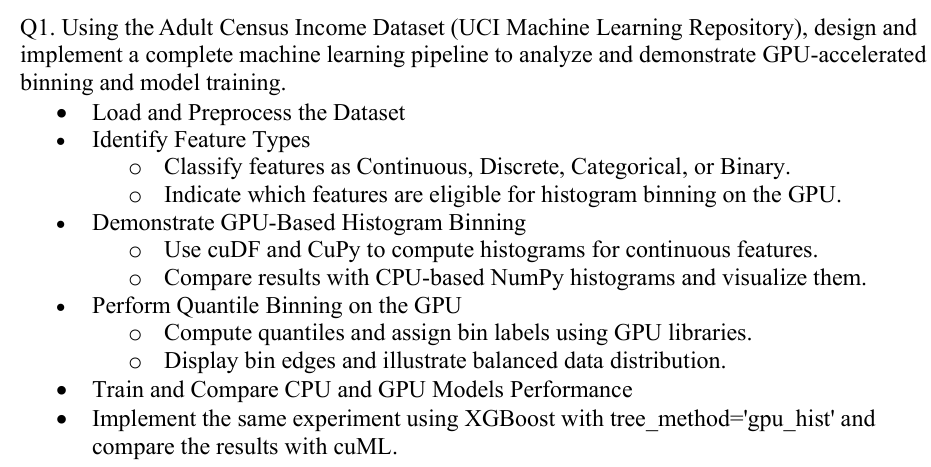

In [6]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
import cudf
import cupy as cp
from cuml.ensemble import RandomForestClassifier as cuRFC
from cuml.preprocessing import LabelEncoder as cuLabelEncoder
from sklearn.ensemble import RandomForestClassifier as skRFC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import urllib.request

## 1.1 Load and Preprocess the Dataset

In [7]:
url_train = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
url_test  = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test'

col_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

df_train = pd.read_csv(url_train, names=col_names, sep=',\s*', engine='python', na_values='?')
df_test  = pd.read_csv(url_test,  names=col_names, sep=',\s*', engine='python', na_values='?', skiprows=1)

df_test['income'] = df_test['income'].str.rstrip('.')

df = pd.concat([df_train, df_test], ignore_index=True)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (45222, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 1.2 Identify Feature Types

In [8]:
feature_types = {
    'age':             ('Continuous',   True),
    'workclass':       ('Categorical',  False),
    'fnlwgt':          ('Continuous',   True),
    'education':       ('Categorical',  False),
    'education_num':   ('Discrete',     True),
    'marital_status':  ('Categorical',  False),
    'occupation':      ('Categorical',  False),
    'relationship':    ('Categorical',  False),
    'race':            ('Categorical',  False),
    'sex':             ('Binary',       False),
    'capital_gain':    ('Continuous',   True),
    'capital_loss':    ('Continuous',   True),
    'hours_per_week':  ('Continuous',   True),
    'native_country':  ('Categorical',  False),
    'income':          ('Binary',       False),
}

type_df = pd.DataFrame(
    [(f, t, 'Yes' if e else 'No') for f, (t, e) in feature_types.items()],
    columns=['Feature', 'Type', 'GPU Histogram Binning Eligible']
)
print(type_df.to_string(index=False))

       Feature        Type GPU Histogram Binning Eligible
           age  Continuous                            Yes
     workclass Categorical                             No
        fnlwgt  Continuous                            Yes
     education Categorical                             No
 education_num    Discrete                            Yes
marital_status Categorical                             No
    occupation Categorical                             No
  relationship Categorical                             No
          race Categorical                             No
           sex      Binary                             No
  capital_gain  Continuous                            Yes
  capital_loss  Continuous                            Yes
hours_per_week  Continuous                            Yes
native_country Categorical                             No
        income      Binary                             No


## 1.3 GPU-Based Histogram Binning vs CPU (NumPy)

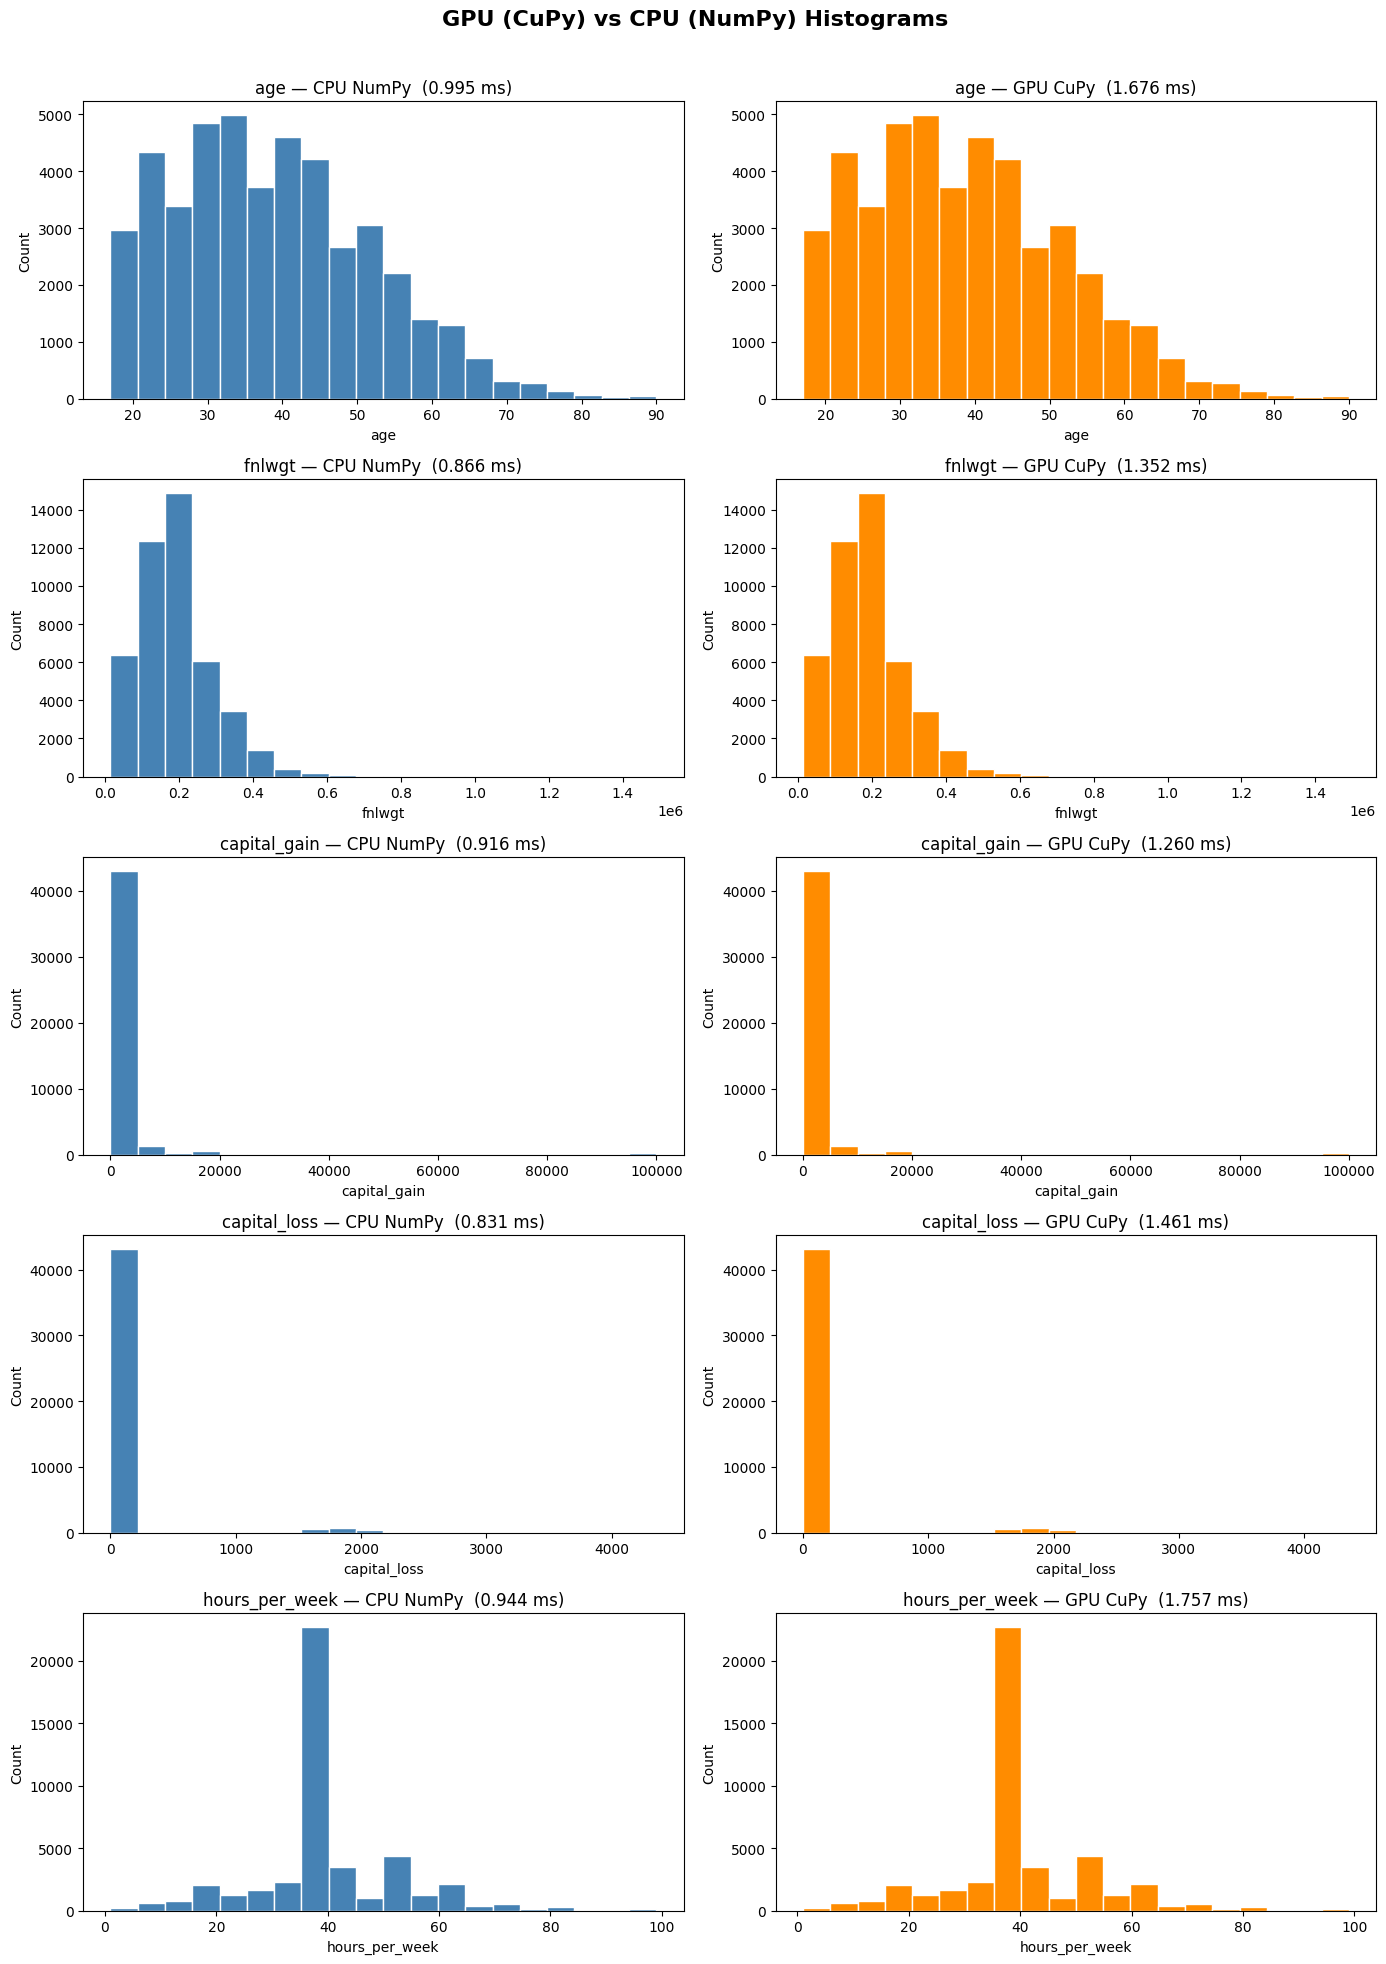


Histogram comparison (first feature):
CPU counts: [ 178  599  799 2026 1255] ...
GPU counts: [ 178  599  799 2026 1255] ...
Arrays match: True


In [9]:
continuous_features = ['age', 'fnlwgt', 'capital_gain', 'capital_loss', 'hours_per_week']
n_bins = 20

fig, axes = plt.subplots(len(continuous_features), 2, figsize=(14, 4 * len(continuous_features)))
fig.suptitle('GPU (CuPy) vs CPU (NumPy) Histograms', fontsize=16, fontweight='bold')

for i, feat in enumerate(continuous_features):
    cpu_data = df[feat].values.astype(np.float64)
    gpu_data = cp.array(cpu_data)

    t0 = time.perf_counter()
    cpu_counts, cpu_edges = np.histogram(cpu_data, bins=n_bins)
    cpu_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    gpu_counts, gpu_edges = cp.histogram(gpu_data, bins=n_bins)
    cp.cuda.Stream.null.synchronize()
    gpu_time = time.perf_counter() - t0

    gpu_counts_np = cp.asnumpy(gpu_counts)
    gpu_edges_np  = cp.asnumpy(gpu_edges)

    ax_cpu = axes[i][0]
    ax_gpu = axes[i][1]

    ax_cpu.bar(cpu_edges[:-1], cpu_counts, width=np.diff(cpu_edges), align='edge', color='steelblue', edgecolor='white')
    ax_cpu.set_title(f'{feat} — CPU NumPy  ({cpu_time*1000:.3f} ms)')
    ax_cpu.set_xlabel(feat)
    ax_cpu.set_ylabel('Count')

    ax_gpu.bar(gpu_edges_np[:-1], gpu_counts_np, width=np.diff(gpu_edges_np), align='edge', color='darkorange', edgecolor='white')
    ax_gpu.set_title(f'{feat} — GPU CuPy  ({gpu_time*1000:.3f} ms)')
    ax_gpu.set_xlabel(feat)
    ax_gpu.set_ylabel('Count')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

print('\nHistogram comparison (first feature):')
print('CPU counts:', cpu_counts[:5], '...')
print('GPU counts:', gpu_counts_np[:5], '...')
print('Arrays match:', np.allclose(cpu_counts, gpu_counts_np))

## 1.4 Quantile Binning on the GPU


age bin edges: [17. 26. 34. 41. 50. 90.]

fnlwgt bin edges: [  13492.   105939.   158058.4  196385.   260557.8 1490400. ]

capital_gain bin edges: [    0.     0.     0.     0.     0. 99999.]

capital_loss bin edges: [   0.    0.    0.    0.    0. 4356.]

hours_per_week bin edges: [ 1. 36. 40. 40. 50. 99.]


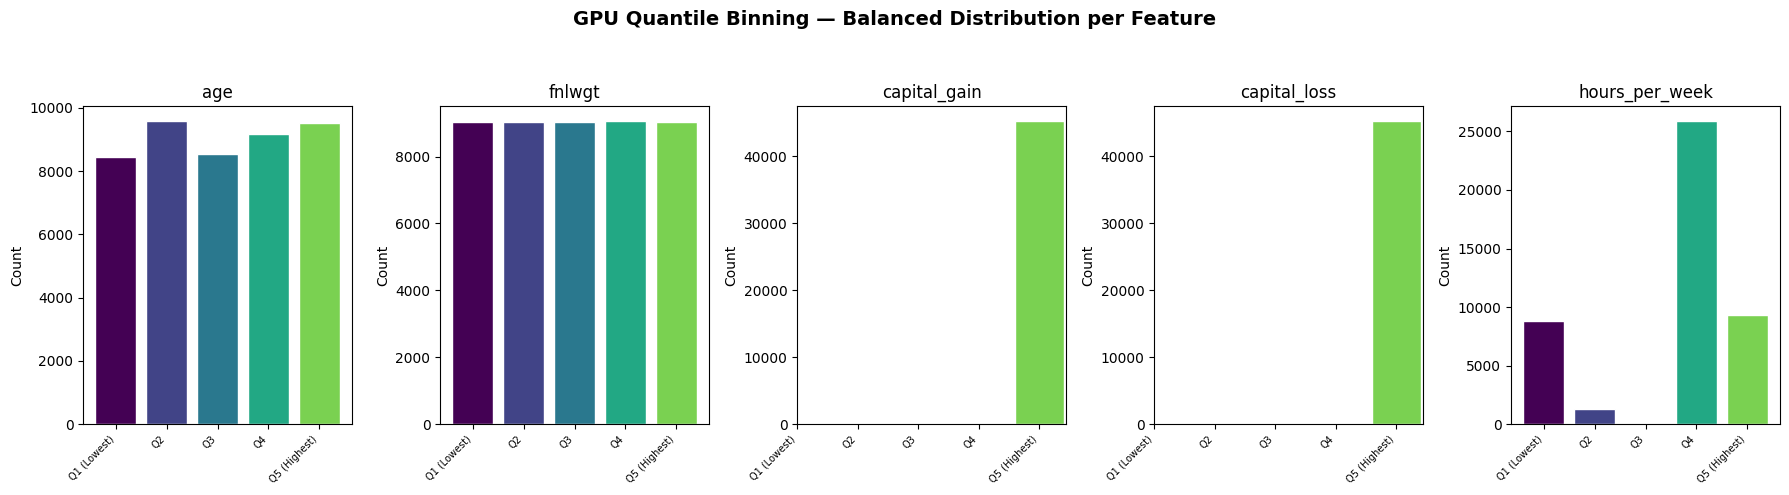

In [10]:
n_quantile_bins = 5
bin_labels = ['Q1 (Lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (Highest)']

# Fix: Use the cudf.DataFrame() constructor directly
cdf = cudf.DataFrame(df[continuous_features])

fig, axes = plt.subplots(1, len(continuous_features), figsize=(18, 5))
fig.suptitle('GPU Quantile Binning — Balanced Distribution per Feature', fontsize=14, fontweight='bold')

for i, feat in enumerate(continuous_features):
    col_gpu = cdf[feat]
    quantile_edges = cp.quantile(col_gpu.values, cp.linspace(0, 1, n_quantile_bins + 1))
    edges_np = cp.asnumpy(quantile_edges)

    print(f'\n{feat} bin edges: {np.round(edges_np, 2)}')

    col_np = cp.asnumpy(col_gpu.values)
    bin_indices = np.digitize(col_np, edges_np[1:-1])
    unique, counts = np.unique(bin_indices, return_counts=True)

    axes[i].bar(unique, counts, color=plt.cm.viridis(unique / n_quantile_bins), edgecolor='white')
    axes[i].set_xticks(range(n_quantile_bins))
    axes[i].set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=7)
    axes[i].set_title(feat)
    axes[i].set_ylabel('Count')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## 1.5 Encode Features and Prepare Data for Modelling

In [11]:
df_enc = df.copy()

categorical_cols = ['workclass', 'education', 'marital_status', 'occupation',
                    'relationship', 'race', 'sex', 'native_country', 'income']

le = LabelEncoder()
for col in categorical_cols:
    df_enc[col] = le.fit_transform(df_enc[col])

X = df_enc.drop('income', axis=1).values.astype(np.float32)
y = df_enc['income'].values.astype(np.int32)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (36177, 14), Test: (9045, 14)


## 1.6 Train and Compare CPU vs GPU Models

In [13]:
results_q1 = {}

sk_clf = skRFC(n_estimators=100, random_state=42, n_jobs=-1)
t0 = time.perf_counter()
sk_clf.fit(X_train, y_train)
sk_train_time = time.perf_counter() - t0

t0 = time.perf_counter()
sk_preds = sk_clf.predict(X_test)
sk_pred_time = time.perf_counter() - t0

sk_acc = accuracy_score(y_test, sk_preds)
results_q1['sklearn RF (CPU)'] = {'Train Time (s)': sk_train_time, 'Predict Time (s)': sk_pred_time, 'Accuracy': sk_acc}

X_train_cu = cudf.DataFrame(X_train)
X_test_cu  = cudf.DataFrame(X_test)
y_train_cu = cudf.Series(y_train)

cu_clf = cuRFC(n_estimators=100, random_state=42)
t0 = time.perf_counter()
cu_clf.fit(X_train_cu, y_train_cu)
cu_train_time = time.perf_counter() - t0

t0 = time.perf_counter()
cu_preds = cu_clf.predict(X_test_cu)
cu_pred_time = time.perf_counter() - t0

cu_acc = accuracy_score(y_test, cp.asnumpy(cu_preds.values))
results_q1['cuML RF (GPU)'] = {'Train Time (s)': cu_train_time, 'Predict Time (s)': cu_pred_time, 'Accuracy': cu_acc}

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test,  label=y_test)

# Updated parameters for modern XGBoost GPU acceleration
params_gpu = {'tree_method': 'hist', 'device': 'cuda', 'eval_metric': 'logloss', 'objective': 'binary:logistic', 'random_state': 42}
t0 = time.perf_counter()
xgb_gpu_model = xgb.train(params_gpu, dtrain, num_boost_round=100, verbose_eval=False)
xgb_gpu_train = time.perf_counter() - t0

t0 = time.perf_counter()
xgb_gpu_prob = xgb_gpu_model.predict(dtest)
xgb_gpu_pred = time.perf_counter() - t0

xgb_gpu_preds = (xgb_gpu_prob > 0.5).astype(int)
xgb_gpu_acc = accuracy_score(y_test, xgb_gpu_preds)
results_q1['XGBoost GPU hist'] = {'Train Time (s)': xgb_gpu_train, 'Predict Time (s)': xgb_gpu_pred, 'Accuracy': xgb_gpu_acc}

params_cpu = {'tree_method': 'hist', 'eval_metric': 'logloss', 'objective': 'binary:logistic', 'random_state': 42}
t0 = time.perf_counter()
xgb_cpu_model = xgb.train(params_cpu, dtrain, num_boost_round=100, verbose_eval=False)
xgb_cpu_train = time.perf_counter() - t0

t0 = time.perf_counter()
xgb_cpu_prob = xgb_cpu_model.predict(dtest)
xgb_cpu_pred = time.perf_counter() - t0

xgb_cpu_preds = (xgb_cpu_prob > 0.5).astype(int)
xgb_cpu_acc = accuracy_score(y_test, xgb_cpu_preds)
results_q1['XGBoost CPU hist'] = {'Train Time (s)': xgb_cpu_train, 'Predict Time (s)': xgb_cpu_pred, 'Accuracy': xgb_cpu_acc}

results_df_q1 = pd.DataFrame(results_q1).T
results_df_q1['Accuracy'] = results_df_q1['Accuracy'].map('{:.4f}'.format)
results_df_q1['Train Time (s)'] = results_df_q1['Train Time (s)'].map('{:.4f}'.format)
results_df_q1['Predict Time (s)'] = results_df_q1['Predict Time (s)'].map('{:.6f}'.format)
print('\n=== Q1 Model Comparison ===')
print(results_df_q1.to_string())


=== Q1 Model Comparison ===
                 Train Time (s) Predict Time (s) Accuracy
sklearn RF (CPU)         5.7730         0.213976   0.8576
cuML RF (GPU)            0.5568         0.127865   0.8607
XGBoost GPU hist         0.5564         0.059478   0.8733
XGBoost CPU hist         0.4471         0.015661   0.8729


## 1.7 Visualise Q1 Model Comparison

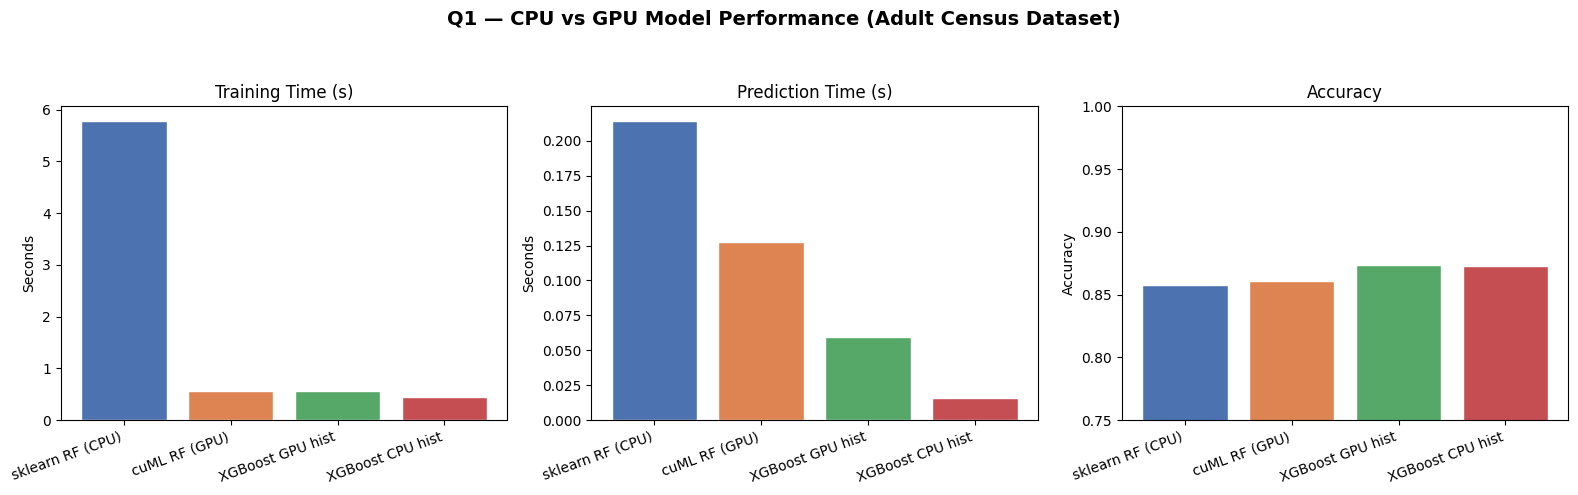

In [14]:
models    = list(results_q1.keys())
train_t   = [results_q1[m]['Train Time (s)']   for m in models]
pred_t    = [results_q1[m]['Predict Time (s)']  for m in models]
accs      = [results_q1[m]['Accuracy']           for m in models]

x = np.arange(len(models))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Q1 — CPU vs GPU Model Performance (Adult Census Dataset)', fontsize=14, fontweight='bold')

axes[0].bar(x, train_t, color=colors, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=20, ha='right')
axes[0].set_title('Training Time (s)')
axes[0].set_ylabel('Seconds')

axes[1].bar(x, pred_t, color=colors, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=20, ha='right')
axes[1].set_title('Prediction Time (s)')
axes[1].set_ylabel('Seconds')

axes[2].bar(x, accs, color=colors, edgecolor='white')
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, rotation=20, ha='right')
axes[2].set_title('Accuracy')
axes[2].set_ylabel('Accuracy')
axes[2].set_ylim([0.75, 1.0])

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

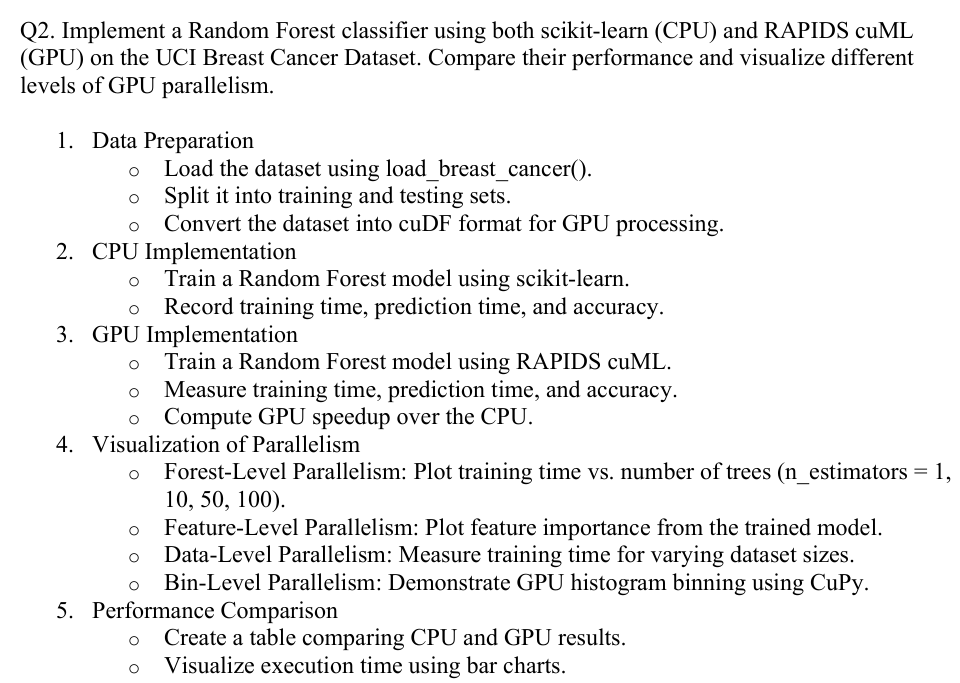

## 2.1 Data Preparation

In [15]:
bc = load_breast_cancer()
X_bc = bc.data.astype(np.float32)
y_bc = bc.target.astype(np.int32)

X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42
)

X_bc_train_cu = cudf.DataFrame(X_bc_train)
X_bc_test_cu  = cudf.DataFrame(X_bc_test)
y_bc_train_cu = cudf.Series(y_bc_train)

print(f'Breast Cancer — Train: {X_bc_train.shape}, Test: {X_bc_test.shape}')
print(f'Feature names: {bc.feature_names[:5]} ...')

Breast Cancer — Train: (455, 30), Test: (114, 30)
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness'] ...


## 2.2 CPU Implementation (scikit-learn)

In [16]:
sk_bc = skRFC(n_estimators=100, random_state=42, n_jobs=-1)

t0 = time.perf_counter()
sk_bc.fit(X_bc_train, y_bc_train)
sk_bc_train_time = time.perf_counter() - t0

t0 = time.perf_counter()
sk_bc_preds = sk_bc.predict(X_bc_test)
sk_bc_pred_time = time.perf_counter() - t0

sk_bc_acc = accuracy_score(y_bc_test, sk_bc_preds)

print(f'[CPU] Train time  : {sk_bc_train_time:.4f} s')
print(f'[CPU] Predict time: {sk_bc_pred_time:.6f} s')
print(f'[CPU] Accuracy    : {sk_bc_acc:.4f}')

[CPU] Train time  : 0.4118 s
[CPU] Predict time: 0.033318 s
[CPU] Accuracy    : 0.9649


## 2.3 GPU Implementation (cuML)

In [17]:
cu_bc = cuRFC(n_estimators=100, random_state=42)

t0 = time.perf_counter()
cu_bc.fit(X_bc_train_cu, y_bc_train_cu)
cu_bc_train_time = time.perf_counter() - t0

t0 = time.perf_counter()
cu_bc_preds = cu_bc.predict(X_bc_test_cu)
cu_bc_pred_time = time.perf_counter() - t0

cu_bc_preds_np = cp.asnumpy(cu_bc_preds.values)
cu_bc_acc = accuracy_score(y_bc_test, cu_bc_preds_np)

train_speedup = sk_bc_train_time / cu_bc_train_time
pred_speedup  = sk_bc_pred_time  / cu_bc_pred_time

print(f'[GPU] Train time  : {cu_bc_train_time:.4f} s')
print(f'[GPU] Predict time: {cu_bc_pred_time:.6f} s')
print(f'[GPU] Accuracy    : {cu_bc_acc:.4f}')
print(f'\nGPU Speedup (Training)  : {train_speedup:.2f}x')
print(f'GPU Speedup (Prediction): {pred_speedup:.2f}x')

[GPU] Train time  : 0.2813 s
[GPU] Predict time: 0.003552 s
[GPU] Accuracy    : 0.9649

GPU Speedup (Training)  : 1.46x
GPU Speedup (Prediction): 9.38x


## 2.4 Visualisation of Parallelism

### 2.4.1 Forest-Level Parallelism — Training Time vs n_estimators

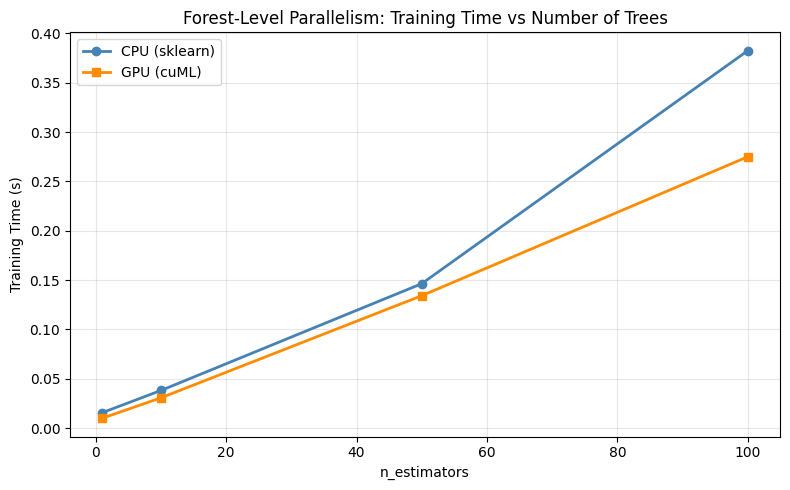

In [18]:
n_estimators_list = [1, 10, 50, 100]

sk_times_forest = []
cu_times_forest = []

for n in n_estimators_list:
    m_sk = skRFC(n_estimators=n, random_state=42, n_jobs=-1)
    t0 = time.perf_counter()
    m_sk.fit(X_bc_train, y_bc_train)
    sk_times_forest.append(time.perf_counter() - t0)

    m_cu = cuRFC(n_estimators=n, random_state=42)
    t0 = time.perf_counter()
    m_cu.fit(X_bc_train_cu, y_bc_train_cu)
    cu_times_forest.append(time.perf_counter() - t0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_estimators_list, sk_times_forest, 'o-', color='steelblue', label='CPU (sklearn)', linewidth=2)
ax.plot(n_estimators_list, cu_times_forest, 's-', color='darkorange', label='GPU (cuML)',   linewidth=2)
ax.set_xlabel('n_estimators')
ax.set_ylabel('Training Time (s)')
ax.set_title('Forest-Level Parallelism: Training Time vs Number of Trees')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.4.2 Feature-Level Parallelism — Feature Importances

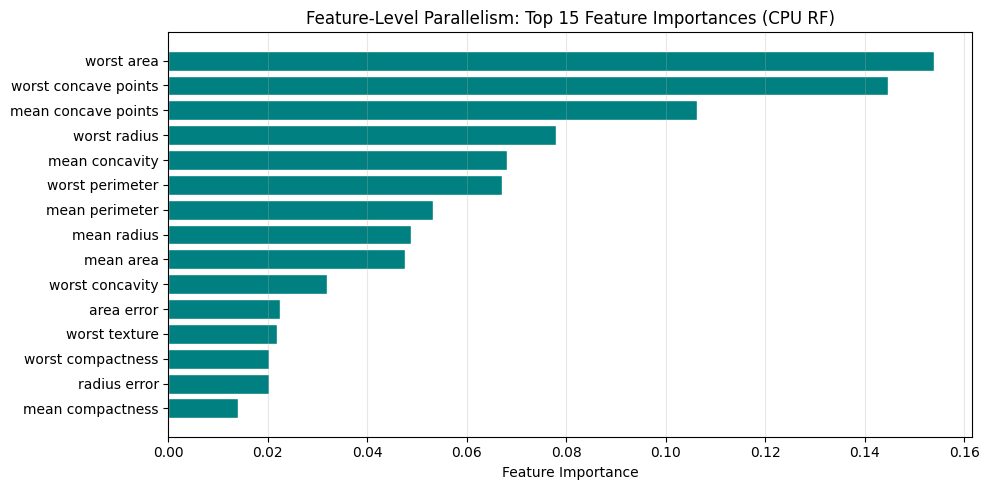

In [19]:
importances = sk_bc.feature_importances_
indices = np.argsort(importances)[::-1][:15]
top_features = [bc.feature_names[i] for i in indices]
top_importances = importances[indices]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_features[::-1], top_importances[::-1], color='teal', edgecolor='white')
ax.set_xlabel('Feature Importance')
ax.set_title('Feature-Level Parallelism: Top 15 Feature Importances (CPU RF)')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 2.4.3 Data-Level Parallelism — Training Time vs Dataset Size

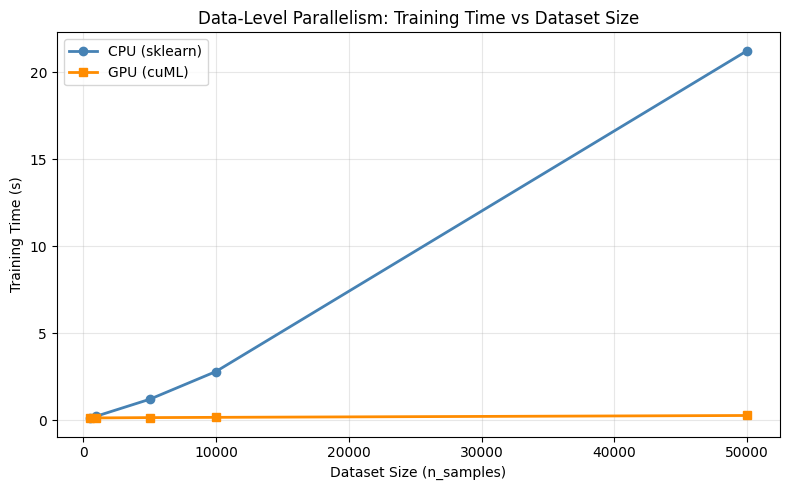

In [20]:
from sklearn.datasets import make_classification

data_sizes = [500, 1000, 5000, 10000, 50000]
sk_times_data = []
cu_times_data = []

for n in data_sizes:
    X_s, y_s = make_classification(n_samples=n, n_features=30, random_state=42)
    X_s = X_s.astype(np.float32)
    y_s = y_s.astype(np.int32)

    m_sk = skRFC(n_estimators=50, random_state=42, n_jobs=-1)
    t0 = time.perf_counter()
    m_sk.fit(X_s, y_s)
    sk_times_data.append(time.perf_counter() - t0)

    X_s_cu = cudf.DataFrame(X_s)
    y_s_cu = cudf.Series(y_s)
    m_cu = cuRFC(n_estimators=50, random_state=42)
    t0 = time.perf_counter()
    m_cu.fit(X_s_cu, y_s_cu)
    cu_times_data.append(time.perf_counter() - t0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(data_sizes, sk_times_data, 'o-', color='steelblue', label='CPU (sklearn)', linewidth=2)
ax.plot(data_sizes, cu_times_data, 's-', color='darkorange', label='GPU (cuML)',   linewidth=2)
ax.set_xlabel('Dataset Size (n_samples)')
ax.set_ylabel('Training Time (s)')
ax.set_title('Data-Level Parallelism: Training Time vs Dataset Size')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.4.4 Bin-Level Parallelism — GPU Histogram Binning with CuPy

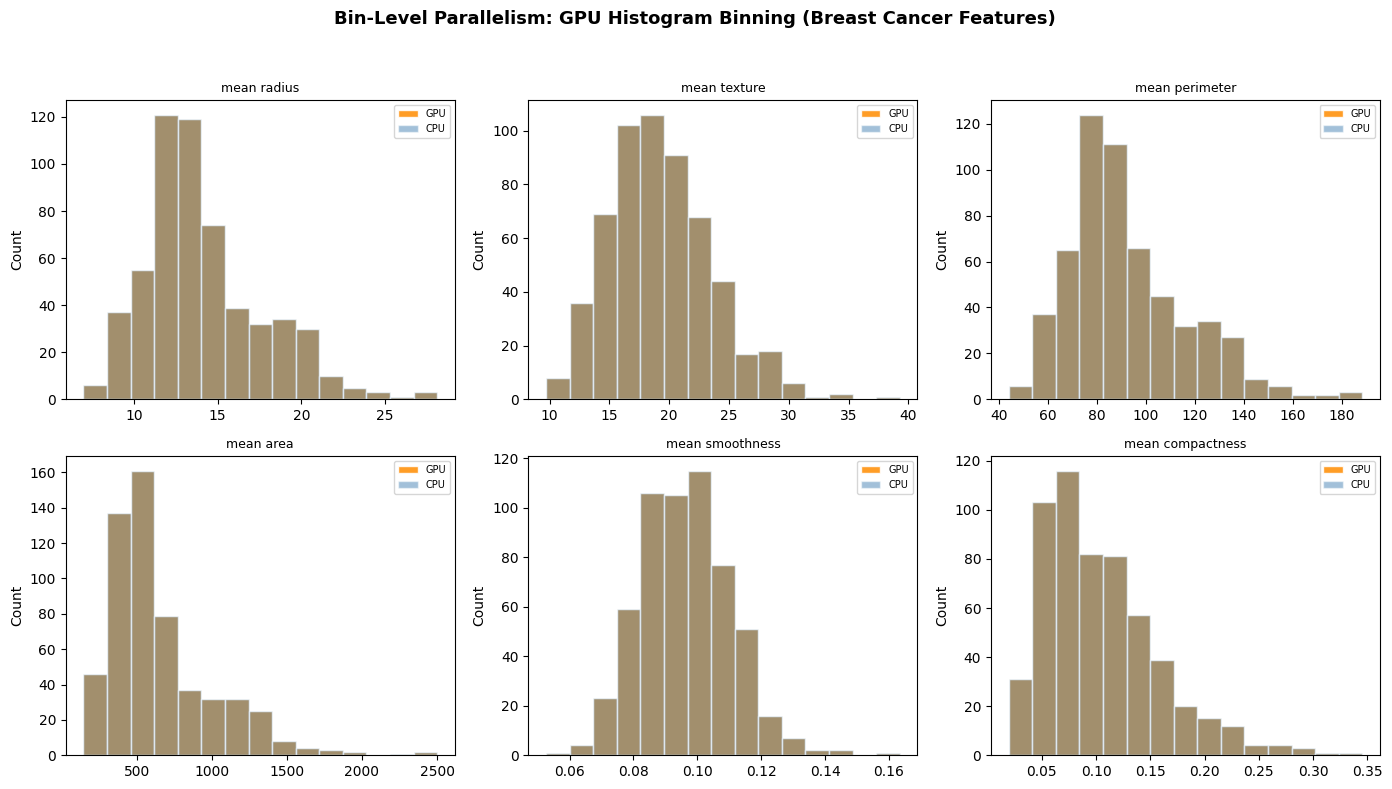


Histogram Timing Summary:
  mean radius                          CPU: 0.2810 ms   GPU: 1676.3335 ms
  mean texture                         CPU: 0.2565 ms   GPU: 2.3101 ms
  mean perimeter                       CPU: 0.2256 ms   GPU: 1.7781 ms
  mean area                            CPU: 0.2234 ms   GPU: 1.7392 ms
  mean smoothness                      CPU: 0.2597 ms   GPU: 2.8542 ms
  mean compactness                     CPU: 0.2355 ms   GPU: 2.0646 ms


In [21]:
selected_features = bc.feature_names[:6]
X_bc_full = bc.data.astype(np.float32)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Bin-Level Parallelism: GPU Histogram Binning (Breast Cancer Features)', fontsize=13, fontweight='bold')
axes = axes.flatten()

cpu_hist_times = []
gpu_hist_times = []

for i, feat_name in enumerate(selected_features):
    col_cpu = X_bc_full[:, i]
    col_gpu = cp.array(col_cpu)

    t0 = time.perf_counter()
    c_cpu, e_cpu = np.histogram(col_cpu, bins=15)
    cpu_hist_times.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    c_gpu, e_gpu = cp.histogram(col_gpu, bins=15)
    cp.cuda.Stream.null.synchronize()
    gpu_hist_times.append(time.perf_counter() - t0)

    c_gpu_np = cp.asnumpy(c_gpu)
    e_gpu_np = cp.asnumpy(e_gpu)

    axes[i].bar(e_gpu_np[:-1], c_gpu_np, width=np.diff(e_gpu_np), align='edge',
                color='darkorange', edgecolor='white', alpha=0.85, label='GPU')
    axes[i].bar(e_cpu[:-1], c_cpu, width=np.diff(e_cpu), align='edge',
                color='steelblue', edgecolor='white', alpha=0.5, label='CPU')
    axes[i].set_title(feat_name, fontsize=9)
    axes[i].legend(fontsize=7)
    axes[i].set_ylabel('Count')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print('\nHistogram Timing Summary:')
for feat_name, ct, gt in zip(selected_features, cpu_hist_times, gpu_hist_times):
    print(f'  {feat_name:35s}  CPU: {ct*1000:.4f} ms   GPU: {gt*1000:.4f} ms')

## 2.5 Performance Comparison Table and Bar Charts

In [22]:
comparison = {
    'Metric': ['Training Time (s)', 'Prediction Time (s)', 'Accuracy', 'Train Speedup', 'Pred Speedup'],
    'CPU (sklearn)': [
        f'{sk_bc_train_time:.4f}',
        f'{sk_bc_pred_time:.6f}',
        f'{sk_bc_acc:.4f}',
        '1.00x (baseline)',
        '1.00x (baseline)'
    ],
    'GPU (cuML)': [
        f'{cu_bc_train_time:.4f}',
        f'{cu_bc_pred_time:.6f}',
        f'{cu_bc_acc:.4f}',
        f'{train_speedup:.2f}x',
        f'{pred_speedup:.2f}x'
    ]
}

comparison_df = pd.DataFrame(comparison)
print('=== Q2 Performance Comparison Table (Breast Cancer Dataset) ===')
print(comparison_df.to_string(index=False))

=== Q2 Performance Comparison Table (Breast Cancer Dataset) ===
             Metric    CPU (sklearn) GPU (cuML)
  Training Time (s)           0.4118     0.2813
Prediction Time (s)         0.033318   0.003552
           Accuracy           0.9649     0.9649
      Train Speedup 1.00x (baseline)      1.46x
       Pred Speedup 1.00x (baseline)      9.38x


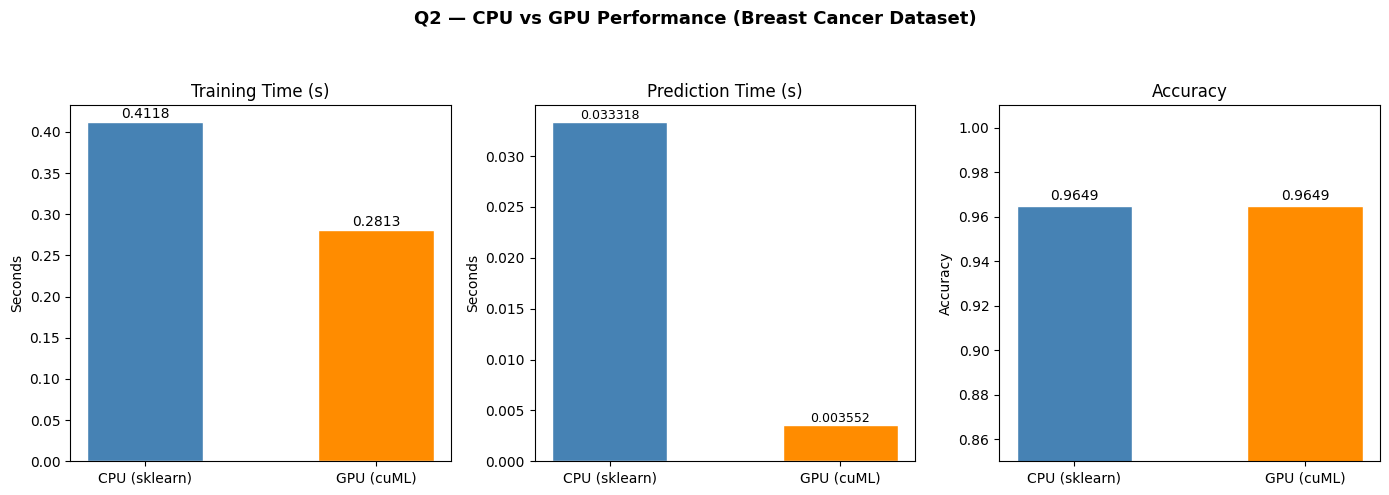

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Q2 — CPU vs GPU Performance (Breast Cancer Dataset)', fontsize=13, fontweight='bold')

bars0 = axes[0].bar(['CPU (sklearn)', 'GPU (cuML)'], [sk_bc_train_time, cu_bc_train_time],
                     color=['steelblue', 'darkorange'], edgecolor='white', width=0.5)
axes[0].set_title('Training Time (s)')
axes[0].set_ylabel('Seconds')
for bar in bars0:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)

bars1 = axes[1].bar(['CPU (sklearn)', 'GPU (cuML)'], [sk_bc_pred_time, cu_bc_pred_time],
                     color=['steelblue', 'darkorange'], edgecolor='white', width=0.5)
axes[1].set_title('Prediction Time (s)')
axes[1].set_ylabel('Seconds')
for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.00001,
                 f'{bar.get_height():.6f}', ha='center', va='bottom', fontsize=9)

bars2 = axes[2].bar(['CPU (sklearn)', 'GPU (cuML)'], [sk_bc_acc, cu_bc_acc],
                     color=['steelblue', 'darkorange'], edgecolor='white', width=0.5)
axes[2].set_title('Accuracy')
axes[2].set_ylabel('Accuracy')
axes[2].set_ylim([0.85, 1.01])
for bar in bars2:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## 2.6 Summary of GPU Speedup

In [24]:
speedup_data = {
    'Parallelism Type': ['Forest-Level (100 trees)', 'Data-Level (50k samples)', 'Training Overall', 'Prediction Overall'],
    'GPU Speedup': [
        f'{sk_times_forest[-1] / cu_times_forest[-1]:.2f}x',
        f'{sk_times_data[-1]  / cu_times_data[-1]:.2f}x',
        f'{train_speedup:.2f}x',
        f'{pred_speedup:.2f}x'
    ]
}
print(pd.DataFrame(speedup_data).to_string(index=False))

        Parallelism Type GPU Speedup
Forest-Level (100 trees)       1.39x
Data-Level (50k samples)      73.87x
        Training Overall       1.46x
      Prediction Overall       9.38x
